# Klasterovanje kupaca

Cilj ovog notebook-a je identifikacija grupa kupaca sa slicnim obrascima ponasanja.

Analiza se zasniva na tabeli `customer_master`, koja sadrzi agregirane informacije o svakom jedinstvenom kupcu. U ovom delu projekta primenjuju se dva algoritma klasterovanja:

- KMeans
- BIRCH

Posto se nakon kodiranja kategorickih atributa dobija veci broj atributa, prvo se ispituje dimenzionalnost podataka i zatim se primenjuje PCA reprezentacija koja cuva 90% ukupne varijanse. Na taj nacin se smanjuje dimenzionalnost problema, ubrzava rad algoritama i smanjuje memorijsko opterecenje.

## Ucitavanje biblioteka

U ovoj celiji ucitavaju se biblioteke potrebne za obradu podataka, vizuelizaciju, transformaciju atributa, redukciju dimenzionalnosti i klasterovanje.

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, Birch
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Ucitavanje podataka

Ucitava se tabela `customer_master`, formirana u prethodnom notebook-u. Jedan red u ovoj tabeli predstavlja jednog jedinstvenog kupca.

In [2]:
customer_master = pd.read_csv("../data/processed/customer_master.csv")

customer_master.shape

(96096, 22)

In [3]:
customer_master.head()

,customer_unique_id,order_count,total_spent,total_items_value,total_freight_value,avg_order_value,avg_item_price,avg_freight_value,avg_items_count,avg_payment_installments,...,avg_estimated_delivery_days,avg_delay_days,delayed_order_rate,unique_products,unique_categories,customer_state,preferred_category,preferred_payment_type,recency_days,customer_lifetime_days
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,129.90,12.00,141.90,129.90,12.00,1.0,8.0,...,10.0,-5.0,0.0,1.0,1,SP,bed_bath_table,credit_card,160,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,18.90,8.29,27.19,18.90,8.29,1.0,1.0,...,7.0,-5.0,0.0,1.0,1,SP,health_beauty,credit_card,163,0
2,0000f46a3911fa3c0805444483337064,1,86.22,69.00,17.22,86.22,69.00,17.22,1.0,8.0,...,27.0,-2.0,0.0,1.0,1,SC,stationery,credit_card,585,0
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,25.99,17.63,43.62,25.99,17.63,1.0,4.0,...,31.0,-12.0,0.0,1.0,1,PA,telephony,credit_card,369,0
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,180.00,16.89,196.89,180.00,16.89,1.0,6.0,...,20.0,-8.0,0.0,1.0,1,SP,telephony,credit_card,336,0


## Pregled atributa

Pre modelovanja proverava se struktura tabele, tipovi atributa i prisustvo nedostajucih vrednosti. Ovaj korak je vazan jer algoritmi klasterovanja zahtevaju numericku i uredjenu reprezentaciju podataka.

In [4]:
customer_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96096 entries, 0 to 96095
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   customer_unique_id           96096 non-null  object 
 1   order_count                  96096 non-null  int64  
 2   total_spent                  96096 non-null  float64
 3   total_items_value            96096 non-null  float64
 4   total_freight_value          96096 non-null  float64
 5   avg_order_value              96096 non-null  float64
 6   avg_item_price               96096 non-null  float64
 7   avg_freight_value            96096 non-null  float64
 8   avg_items_count              96096 non-null  float64
 9   avg_payment_installments     96096 non-null  float64
 10  avg_review_score             96096 non-null  float64
 11  avg_delivery_days            96096 non-null  float64
 12  avg_estimated_delivery_days  96096 non-null  float64
 13  avg_delay_days  

In [5]:
missing_values = (
    customer_master
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_values[missing_values > 0]

Series([], dtype: int64)

## Izbor atributa za klasterovanje

Za klasterovanje se koriste numericki atributi koji opisuju aktivnost kupca, potrosnju, broj kupljenih proizvoda, zadovoljstvo, isporuku i vremensku aktivnost.

Pored numerickih atributa ukljucuju se i kategoricki atributi koji opisuju geografsku lokaciju, najcescu kategoriju proizvoda i najcesci nacin placanja. Ovi atributi se kodiraju metodom One-Hot Encoding.

Identifikator kupca se ne koristi u procesu klasterovanja jer ne nosi informaciju o ponasanju kupca.

In [6]:
id_columns = ["customer_unique_id"]

numeric_features = [
    "order_count",
    "total_spent",
    "total_items_value",
    "total_freight_value",
    "avg_order_value",
    "avg_item_price",
    "avg_freight_value",
    "avg_items_count",
    "avg_payment_installments",
    "avg_review_score",
    "avg_delivery_days",
    "avg_estimated_delivery_days",
    "avg_delay_days",
    "delayed_order_rate",
    "unique_products",
    "unique_categories",
    "recency_days",
    "customer_lifetime_days"
]

categorical_features = [
    "customer_state",
    "preferred_category",
    "preferred_payment_type"
]

numeric_features = [col for col in numeric_features if col in customer_master.columns]
categorical_features = [col for col in categorical_features if col in customer_master.columns]

print("Broj numerickih atributa:", len(numeric_features))
print("Broj kategorickih atributa:", len(categorical_features))
print("Numericki atributi:", numeric_features)
print("Kategoricki atributi:", categorical_features)

Broj numerickih atributa: 18
Broj kategorickih atributa: 3
Numericki atributi: ['order_count', 'total_spent', 'total_items_value', 'total_freight_value', 'avg_order_value', 'avg_item_price', 'avg_freight_value', 'avg_items_count', 'avg_payment_installments', 'avg_review_score', 'avg_delivery_days', 'avg_estimated_delivery_days', 'avg_delay_days', 'delayed_order_rate', 'unique_products', 'unique_categories', 'recency_days', 'customer_lifetime_days']
Kategoricki atributi: ['customer_state', 'preferred_category', 'preferred_payment_type']


## Priprema radne tabele

In [7]:
customer_master_clean = customer_master.copy()

customer_master_clean[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
order_count,96096.0,1.034809,0.214384,1.00,1.00,1.000,1.00,17.00
total_spent,96096.0,166.592492,231.428332,0.00,63.12,108.000,183.53,13664.08
total_items_value,96096.0,141.438184,217.215904,0.00,45.99,89.000,154.00,13440.00
total_freight_value,96096.0,23.433957,22.883215,0.00,13.92,17.530,25.42,1794.96
avg_order_value,96096.0,161.401217,222.306993,0.00,62.46,105.830,177.21,13664.08
avg_item_price,96096.0,126.224340,191.116243,0.85,43.00,79.445,139.90,6735.00
avg_freight_value,96096.0,22.779804,21.489966,0.00,13.92,17.240,23.99,1794.96
avg_items_count,96096.0,1.138122,0.525152,1.00,1.00,1.000,1.00,21.00
avg_payment_installments,96096.0,2.901875,2.677691,0.00,1.00,2.000,4.00,24.00
avg_review_score,96096.0,4.091781,1.338968,1.00,4.00,5.000,5.00,5.00


## Distribucije numerickih atributa

Veci broj atributa ima asimetricnu raspodelu, sto je ocekivano kod podataka o kupovini. Mali broj kupaca ima veliki broj porudzbina ili veoma visoku potrosnju, dok vecina kupaca ima manju aktivnost.

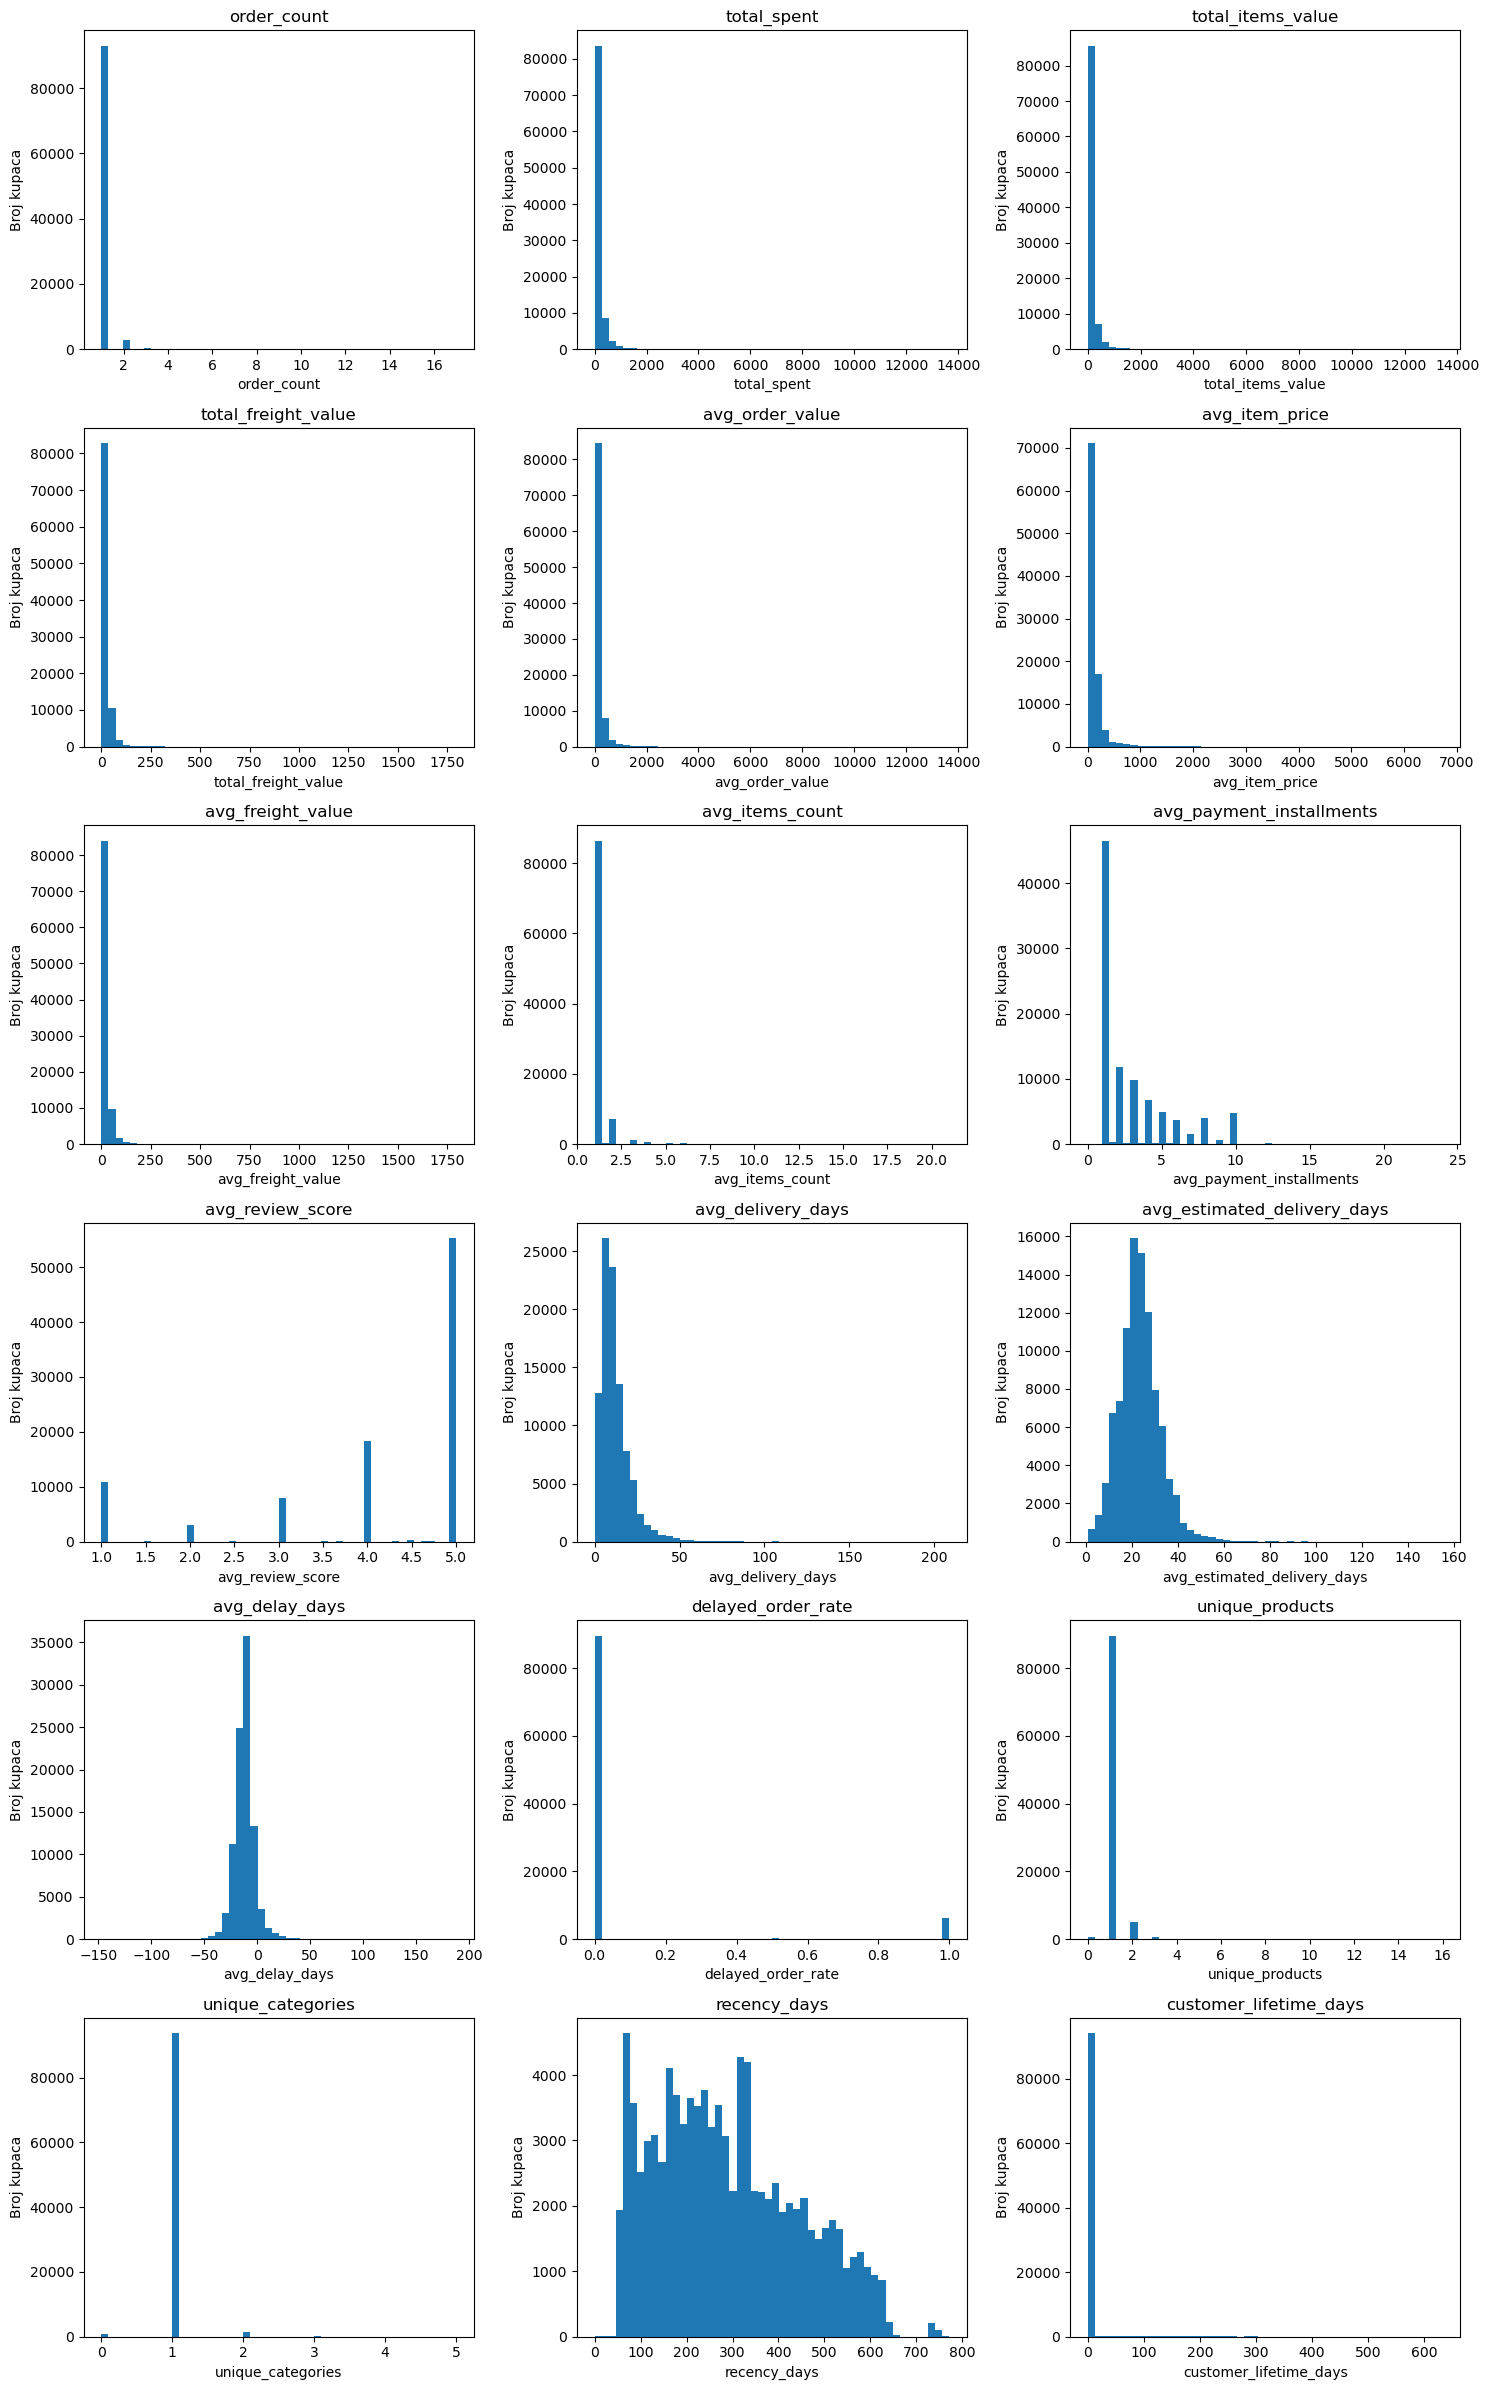

In [8]:
selected_distribution_features = [
     "order_count",
    "total_spent",
    "total_items_value",
    "total_freight_value",
    "avg_order_value",
    "avg_item_price",
    "avg_freight_value",
    "avg_items_count",
    "avg_payment_installments",
    "avg_review_score",
    "avg_delivery_days",
    "avg_estimated_delivery_days",
    "avg_delay_days",
    "delayed_order_rate",
    "unique_products",
    "unique_categories",
    "recency_days",
    "customer_lifetime_days"
]

selected_distribution_features = [
    col for col in selected_distribution_features
    if col in customer_master_clean.columns
]

n_cols = 3
n_rows = (len(selected_distribution_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = np.array(axes).flatten()

for i, col in enumerate(selected_distribution_features):
    axes[i].hist(customer_master_clean[col].dropna(), bins=50)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Broj kupaca")

for j in range(len(selected_distribution_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Log transformacija

Atributi koji opisuju potrosnju, broj proizvoda i vremensku aktivnost cesto imaju izrazito desno asimetricne raspodele. Zbog toga se nad odabranim nenegativnim atributima primenjuje `log1p` transformacija.

Ova transformacija smanjuje uticaj ekstremno velikih vrednosti, ali ne menja poredak kupaca.

In [9]:
log_features = [
    "order_count",
    "total_spent",
    "total_items_value",
    "total_freight_value",
    "avg_order_value",
    "avg_item_price",
    "avg_freight_value",
    "avg_items_count",
    'avg_delivery_days',
    'avg_estimated_delivery_days',
    "unique_products",
    "unique_categories",
    "recency_days",
    "customer_lifetime_days"
]

log_features = [
    col for col in log_features
    if col in customer_master_clean.columns
]

for col in log_features:
    min_value = customer_master_clean[col].min()
    if min_value >= 0:
        customer_master_clean[col] = np.log1p(customer_master_clean[col])

customer_master_clean[log_features].describe().T

,count,mean,std,min,25%,50%,75%,max
order_count,96096.0,0.706732,0.078259,0.693147,0.693147,0.693147,0.693147,2.890372
total_spent,96096.0,4.733067,0.812062,0.000000,4.160756,4.691348,5.217812,9.522599
total_items_value,96096.0,4.457260,0.995787,0.000000,3.849935,4.499810,5.043425,9.506065
total_freight_value,96096.0,2.989107,0.622313,0.000000,2.702703,2.919391,3.274121,7.493295
avg_order_value,96096.0,4.710377,0.800453,0.000000,4.150410,4.671239,5.182963,9.522599
avg_item_price,96096.0,4.386264,0.900440,0.615186,3.784190,4.387574,4.948050,8.815222
avg_freight_value,96096.0,2.988137,0.553489,0.000000,2.702703,2.903617,3.218476,7.493295
avg_items_count,96096.0,0.742786,0.164039,0.693147,0.693147,0.693147,0.693147,3.091042
avg_delivery_days,96096.0,2.372523,0.626869,0.000000,1.945910,2.397895,2.772589,5.347108
avg_estimated_delivery_days,96096.0,3.124055,0.394507,0.693147,2.944439,3.178054,3.367296,5.049856


## Kodiranje i skaliranje atributa

Numericki atributi se popunjavaju medijanom i zatim standardizuju. Kategoricki atributi se popunjavaju vrednoscu `unknown` i zatim kodiraju metodom One-Hot Encoding.

Na kraju se dobija numericka matrica pogodna za PCA i algoritme klasterovanja.

In [10]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

X_prepared = preprocessor.fit_transform(customer_master_clean)
X_prepared = X_prepared.astype(np.float32)

X_prepared.shape

(96096, 125)

## Analiza dimenzionalnosti

Nakon kodiranja kategorickih atributa broj atributa se znacajno povecava. Zbog toga se primenjuje PCA kako bi se proverilo koliko komponenti je potrebno za ocuvanje najveceg dela informacija.

U nastavku se posmatra kumulativno objasnjena varijansa.

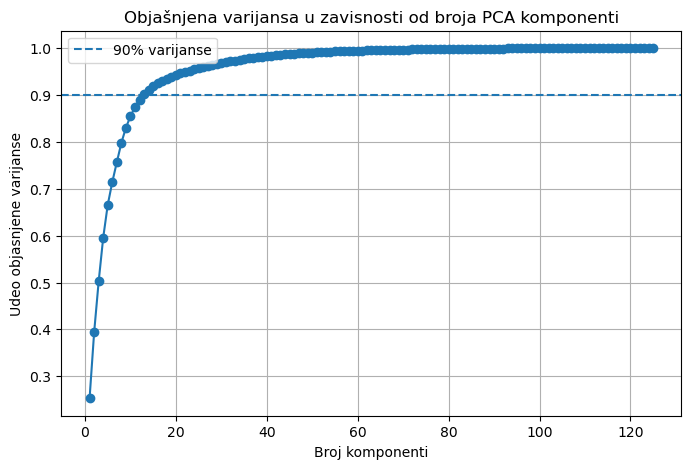

Broj komponenti potreban za 90% varijanse: 13
Ukupan broj atributa nakon pripreme: 125


In [11]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_prepared)

explained_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(explained_variance) + 1),
    explained_variance,
    marker="o"
)
plt.axhline(y=0.90, linestyle="--", label="90% varijanse")
plt.title("Objašnjena varijansa u zavisnosti od broja PCA komponenti")
plt.xlabel("Broj komponenti")
plt.ylabel("Udeo objasnjene varijanse")
plt.grid(True)
plt.legend()
plt.show()

n_components_90 = np.argmax(explained_variance >= 0.90) + 1

print(f"Broj komponenti potreban za 90% varijanse: {n_components_90}")
print(f"Ukupan broj atributa nakon pripreme: {X_prepared.shape[1]}")

## Formiranje PCA prostora

Posto PCA znacajno smanjuje broj atributa, a pritom zadrzava 90% ukupne varijanse, u nastavku se algoritmi klasterovanja treniraju nad PCA reprezentacijom.

Ova odluka je posebno vazna za BIRCH, jer rad nad originalnim prostorom sa velikim brojem atributa moze izazvati veliko memorijsko opterecenje.

In [12]:
pca_90 = PCA(
    n_components=n_components_90,
    random_state=RANDOM_STATE
)

X_pca_90 = pca_90.fit_transform(X_prepared)
X_final = X_pca_90.astype(np.float32)

X_final.shape

(96096, 13)

### Interpretacija glavnih komponenti

Nakon primene PCA originalni skup od 125 atributa transformisan je u 13 glavnih komponenti koje zajedno zadržavaju najmanje 90% ukupne varijanse podataka. Za razliku od metoda selekcije atributa, PCA ne zadržava originalne atribute, već formira nove komponente koje predstavljaju njihove linearne kombinacije.

Radi lakše interpretacije, u nastavku su prikazani atributi sa najvećim apsolutnim opterećenjem za prve tri glavne komponente. Veće apsolutno opterećenje ukazuje na veći doprinos datog atributa formiranju odgovarajuće komponente.

In [13]:
feature_names = preprocessor.get_feature_names_out()

loadings = pd.DataFrame(
    pca_90.components_,
    columns=feature_names,
    index=[f"PC{i+1}" for i in range(pca_90.n_components_)]
)

for pc in loadings.index[:3]:

    top_features = (
        loadings.loc[pc]
        .abs()
        .sort_values(ascending=False)
        .head(10)
        .reset_index()
    )

    top_features.columns = ["Atribut", "Apsolutno opterecenje"]

    print(f"\n{pc}")
    display(top_features)


PC1


,Atribut,Apsolutno opterecenje
0,num__total_spent,0.409474
1,num__total_items_value,0.398461
2,num__avg_order_value,0.396457
3,num__avg_item_price,0.346445
4,num__total_freight_value,0.343353
5,num__avg_freight_value,0.319480
6,num__avg_payment_installments,0.205120
7,num__unique_products,0.171012
8,num__avg_estimated_delivery_days,0.145121
9,num__avg_items_count,0.140902



PC2


,Atribut,Apsolutno opterecenje
0,num__order_count,0.475829
1,num__unique_products,0.454986
2,num__customer_lifetime_days,0.451603
3,num__unique_categories,0.441306
4,num__avg_item_price,0.213127
5,num__avg_order_value,0.192949
6,num__total_spent,0.114288
7,num__avg_delivery_days,0.109481
8,num__total_freight_value,0.105318
9,num__avg_payment_installments,0.099908



PC3


,Atribut,Apsolutno opterecenje
0,num__delayed_order_rate,0.521146
1,num__avg_delivery_days,0.510269
2,num__avg_delay_days,0.450158
3,num__avg_review_score,0.368398
4,num__avg_item_price,0.151922
5,num__total_items_value,0.118538
6,num__avg_estimated_delivery_days,0.111577
7,num__avg_order_value,0.111124
8,num__avg_freight_value,0.109417
9,num__total_freight_value,0.107712


Na osnovu prikazanih rezultata može se uočiti da prva glavna komponenta najveći značaj pridaje atributima koji opisuju finansijsku vrednost kupovine, kao što su ukupna potrošnja, vrednost kupljenih proizvoda i prosečna vrednost porudžbine. Druga komponenta dominantno opisuje intenzitet aktivnosti kupca kroz broj porudžbina, broj različitih proizvoda i trajanje odnosa sa platformom. Treća komponenta najveći značaj pridaje atributima koji se odnose na kašnjenje isporuke i zadovoljstvo kupaca, zbog čega predstavlja komponentu koja opisuje kvalitet procesa isporuke.

## Uzorak za evaluaciju

Metrika silhouette ima visoku racunsku slozenost, pa se evaluacija vrsi nad slucajnim uzorkom kupaca. Modeli se i dalje treniraju nad celim skupom podataka, dok se metrike racunaju nad uzorkom.

In [14]:
SAMPLE_SIZE = min(10000, X_final.shape[0])

sample_idx = np.random.choice(
    X_final.shape[0],
    size=SAMPLE_SIZE,
    replace=False
)

X_sample = X_final[sample_idx]

print("Velicina uzorka za evaluaciju:", X_sample.shape)

Velicina uzorka za evaluaciju: (10000, 13)


## Pomocne funkcije za evaluaciju

Definisu se funkcije koje racunaju interne metrike klasterovanja i raspodelu instanci po klasterima.

Koriste se sledece metrike:

- Silhouette Score - veca vrednost oznacava bolje razdvajanje klastera
- Davies-Bouldin Score - manja vrednost oznacava bolje klastere
- Calinski-Harabasz Score - veca vrednost oznacava bolje razdvajanje klastera

In [15]:
def evaluate_clustering(X_eval, labels):
    unique_labels = np.unique(labels)

    if len(unique_labels) < 2:
        return {
            "silhouette": np.nan,
            "davies_bouldin": np.nan,
            "calinski_harabasz": np.nan
        }

    return {
        "silhouette": silhouette_score(X_eval, labels),
        "davies_bouldin": davies_bouldin_score(X_eval, labels),
        "calinski_harabasz": calinski_harabasz_score(X_eval, labels)
    }


def cluster_distribution(labels):
    return (
        pd.Series(labels)
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )

# KMeans algoritam

KMeans deli podatke na unapred zadat broj klastera tako sto minimizuje rastojanje instanci od centara svojih klastera.

Ovaj algoritam je pogodan za segmentaciju kupaca jer je brz, jednostavan za interpretaciju i dobro radi nad velikim skupovima podataka.

## Izbor broja klastera za KMeans

Modeli se treniraju za vise vrednosti broja klastera. Za svaku vrednost racunaju se interne metrike nad uzorkom.

In [16]:
k_values = range(2, 9)
kmeans_results = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )

    labels = model.fit_predict(X_final)
    labels_sample = labels[sample_idx]
    metrics = evaluate_clustering(X_sample, labels_sample)

    kmeans_results.append({
        "algorithm": "KMeans",
        "k": k,
        **metrics,
        "largest_cluster_share": cluster_distribution(labels).max(),
        "smallest_cluster_share": cluster_distribution(labels).min()    })

kmeans_results = pd.DataFrame(kmeans_results)
kmeans_results

,algorithm,k,silhouette,davies_bouldin,calinski_harabasz,largest_cluster_share,smallest_cluster_share
0,KMeans,2,0.199306,1.916865,2122.105713,57.84,42.16
1,KMeans,3,0.203998,1.516041,1966.456665,55.60,2.60
2,KMeans,4,0.222584,1.368424,1914.140015,51.76,2.59
3,KMeans,5,0.168268,1.588994,1771.973022,42.53,2.57
4,KMeans,6,0.222803,1.242742,1739.312500,46.91,0.70
5,KMeans,7,0.182480,1.345686,1738.979736,35.63,0.70
6,KMeans,8,0.167826,1.338335,1708.382812,32.28,0.70


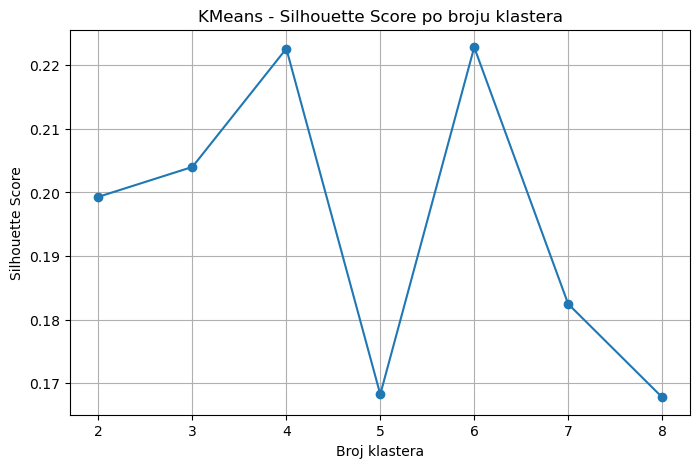

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(kmeans_results["k"], kmeans_results["silhouette"], marker="o")
plt.title("KMeans - Silhouette Score po broju klastera")
plt.xlabel("Broj klastera")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

## Raspodela klastera za KMeans

Pored vrednosti metrika, vazno je proveriti i raspodelu kupaca po klasterima. Model sa dobrim metrikama, ali ekstremno neuravnotezenim klasterima, moze biti los za interpretaciju.

In [18]:
for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )

    labels = model.fit_predict(X_final)

    print(f"KMeans, k={k}")
    print(cluster_distribution(labels))
    print("-" * 40)

KMeans, k=2
0    42.16
1    57.84
Name: proportion, dtype: float64
----------------------------------------
KMeans, k=3
0    55.6
1     2.6
2    41.8
Name: proportion, dtype: float64
----------------------------------------
KMeans, k=4
0    51.76
1     2.59
2    39.21
3     6.44
Name: proportion, dtype: float64
----------------------------------------
KMeans, k=5
0    33.64
1     2.57
2    42.53
3     6.31
4    14.94
Name: proportion, dtype: float64
----------------------------------------
KMeans, k=6
0     0.70
1     6.37
2    46.91
3     2.52
4    35.48
5     8.01
Name: proportion, dtype: float64
----------------------------------------
KMeans, k=7
0    28.93
1     7.64
2     0.70
3     6.25
4    18.32
5    35.63
6     2.52
Name: proportion, dtype: float64
----------------------------------------
KMeans, k=8
0     7.43
1    32.28
2     2.51
3    15.97
4    10.18
5    24.79
6     6.15
7     0.70
Name: proportion, dtype: float64
----------------------------------------


## Finalni KMeans model

Finalni broj klastera ne bira se iskljucivo na osnovu Silhouette Score metrike. Pored internih metrika, uzima se u obzir i raspodela instanci po klasterima.

Modeli koji formiraju izrazito male klastere nisu pogodni za interpretaciju, cak i kada ostvaruju bolju vrednost metrike. Zbog toga se prvo odbacuju resenja kod kojih najmanji klaster ima manje od 2.5% kupaca, a zatim se bira model sa najboljim metrikama.

In [19]:
MIN_CLUSTER_SHARE = 2.5

valid_kmeans_results = kmeans_results[
    kmeans_results["smallest_cluster_share"] >= MIN_CLUSTER_SHARE
].copy()

best_kmeans_row = valid_kmeans_results.sort_values(
    by=["silhouette", "calinski_harabasz"],
    ascending=[False, False]
).iloc[0]

best_kmeans_k = int(best_kmeans_row["k"])
best_kmeans_k

4

In [20]:
kmeans_final = KMeans(
    n_clusters=best_kmeans_k,
    random_state=RANDOM_STATE,
    n_init=10
)

customer_master_clean["kmeans_cluster"] = kmeans_final.fit_predict(X_final)

cluster_distribution(customer_master_clean["kmeans_cluster"])

kmeans_cluster
0    51.76
1     2.59
2    39.21
3     6.44
Name: proportion, dtype: float64

## Vizuelizacija KMeans klastera

Za prikaz klastera koriste se prve dve PCA komponente. Ovaj grafik sluzi za vizuelnu procenu razdvojenosti klastera, dok se konacni zakljucak donosi na osnovu metrika i profilisanja klastera.

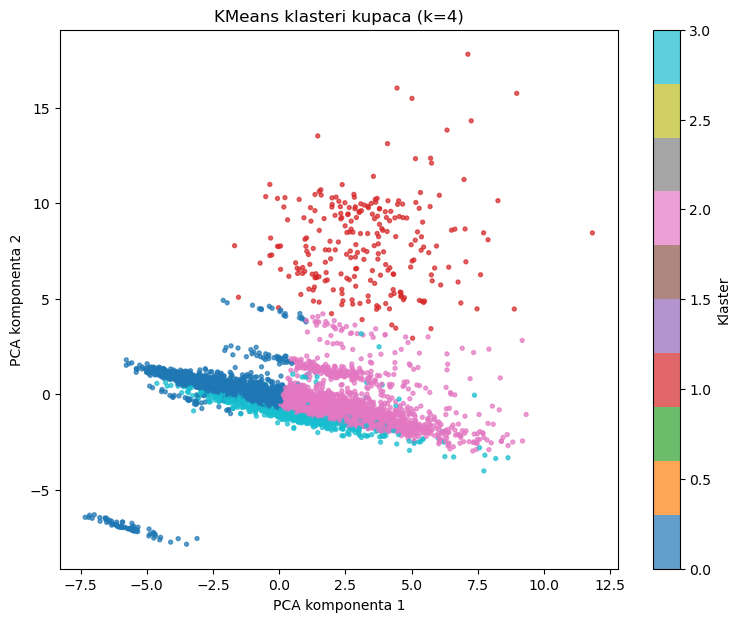

In [21]:
plt.figure(figsize=(9, 7))

scatter = plt.scatter(
    X_final[sample_idx, 0],
    X_final[sample_idx, 1],
    c=customer_master_clean.loc[sample_idx, "kmeans_cluster"],
    s=8,
    alpha=0.7,
    cmap="tab10"
)

plt.title(f"KMeans klasteri kupaca (k={best_kmeans_k})")
plt.xlabel("PCA komponenta 1")
plt.ylabel("PCA komponenta 2")
plt.colorbar(scatter, label="Klaster")
plt.show()

# BIRCH algoritam

BIRCH je algoritam namenjen efikasnom klasterovanju velikih skupova podataka. Umesto da direktno cuva sve instance u procesu klasterovanja, on gradi kompaktnu strukturu koja predstavlja podskupove podataka.

Zbog velikog broja kupaca, BIRCH je prirodan izbor za ovaj deo projekta. Finalno klasterovanje se sprovodi nad PCA reprezentacijom kako bi se izbeglo preveliko memorijsko opterecenje.

## Izbor broja klastera za BIRCH

BIRCH se evaluira za vise vrednosti broja klastera. Koristi se prag `threshold=1.0` i `branching_factor=100`, sto daje stabilniji rad nad vecim skupom kupaca.

In [22]:
birch_results = []

for k in k_values:
    model = Birch(
        n_clusters=k,
        threshold=1.0,
        branching_factor=100
    )

    labels = model.fit_predict(X_final)
    labels_sample = labels[sample_idx]
    metrics = evaluate_clustering(X_sample, labels_sample)

    birch_results.append({
        "algorithm": "BIRCH",
        "k": k,
        **metrics,
        "largest_cluster_share": cluster_distribution(labels).max(),
        "smallest_cluster_share": cluster_distribution(labels).min()
    })

birch_results = pd.DataFrame(birch_results)
birch_results

,algorithm,k,silhouette,davies_bouldin,calinski_harabasz,largest_cluster_share,smallest_cluster_share
0,BIRCH,2,0.510822,1.028750,1286.374023,96.90,3.1
1,BIRCH,3,0.233283,1.545924,1099.835327,88.23,3.1
2,BIRCH,4,0.268874,1.430461,1259.604370,81.80,3.1
3,BIRCH,5,0.166650,1.550521,1543.226685,41.49,3.1
4,BIRCH,6,0.173001,1.350508,1525.671875,40.79,0.7
5,BIRCH,7,0.172090,1.429617,1341.195679,40.79,0.7
6,BIRCH,8,0.142678,1.502697,1297.699951,40.79,0.7


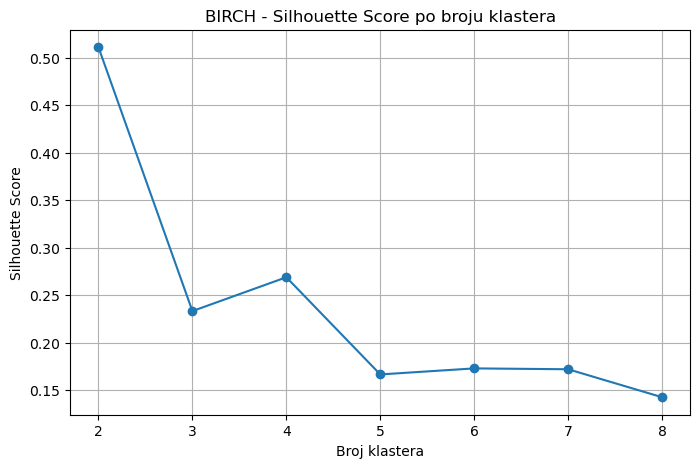

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(birch_results["k"], birch_results["silhouette"], marker="o")
plt.title("BIRCH - Silhouette Score po broju klastera")
plt.xlabel("Broj klastera")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

## Raspodela klastera za BIRCH

Kao i kod KMeans algoritma, pored metrika se proverava i raspodela kupaca po klasterima, kako bismo se uverili da nije doslo do izdvajanja premalih klastera.

In [24]:
for k in k_values:
    model = Birch(
        n_clusters=k,
        threshold=1.0,
        branching_factor=100
    )

    labels = model.fit_predict(X_final)

    print(f"BIRCH, k={k}")
    print(cluster_distribution(labels))
    print("-" * 40)

BIRCH, k=2
0    96.9
1     3.1
Name: proportion, dtype: float64
----------------------------------------
BIRCH, k=3
0    88.23
1     3.10
2     8.68
Name: proportion, dtype: float64
----------------------------------------
BIRCH, k=4
0    81.80
1     3.10
2     8.68
3     6.42
Name: proportion, dtype: float64
----------------------------------------
BIRCH, k=5
0    41.49
1     3.10
2     8.68
3     6.42
4    40.31
Name: proportion, dtype: float64
----------------------------------------
BIRCH, k=6
0     3.10
1    40.31
2     8.68
3     6.42
4    40.79
5     0.70
Name: proportion, dtype: float64
----------------------------------------
BIRCH, k=7
0    40.31
1     1.73
2     8.68
3     6.42
4    40.79
5     0.70
6     1.37
Name: proportion, dtype: float64
----------------------------------------
BIRCH, k=8
0     8.68
1     1.73
2    35.33
3     6.42
4    40.79
5     0.70
6     1.37
7     4.98
Name: proportion, dtype: float64
----------------------------------------


## Finalni BIRCH model

Iako je BIRCH za k=2 ostvario najbolju vrednost interne metrike, dobijeno resenje nije dovoljno informativno za dalju analizu, posto jedan klaster sadrzi gotovo sve kupce.

Kod k=3 situacija se delimično popravlja, ali dominantni klaster i dalje obuhvata vise od 90% instanci.

Zbog toga je za dalju analizu izabran model sa k=4, koji omogucava izdvajanje dodatnih segmenata kupaca i detaljniju interpretaciju rezultata.

In [25]:
best_birch_k = 4


In [26]:
birch_final = Birch(
    n_clusters=best_birch_k,
    threshold=1.0,
    branching_factor=100
)

customer_master_clean["birch_cluster"] = birch_final.fit_predict(X_final)

cluster_distribution(customer_master_clean["birch_cluster"])

birch_cluster
0    81.80
1     3.10
2     8.68
3     6.42
Name: proportion, dtype: float64

## Vizuelizacija BIRCH klastera

BIRCH klasteri se prikazuju u prostoru prve dve PCA komponente kako bi se vizuelno uporedili sa KMeans klasterima.

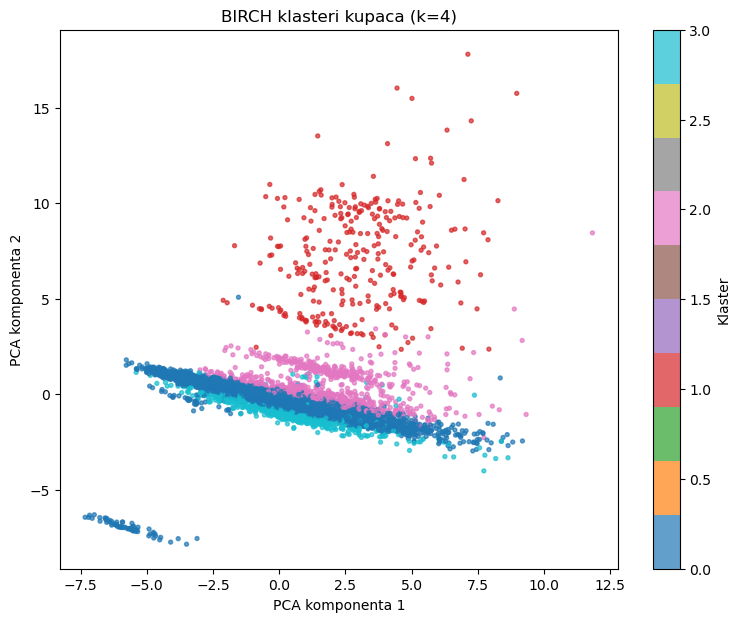

In [27]:
plt.figure(figsize=(9, 7))

scatter = plt.scatter(
    X_final[sample_idx, 0],
    X_final[sample_idx, 1],
    c=customer_master_clean.loc[sample_idx, "birch_cluster"],
    s=8,
    alpha=0.7,
    cmap="tab10"
)

plt.title(f"BIRCH klasteri kupaca (k={best_birch_k})")
plt.xlabel("PCA komponenta 1")
plt.ylabel("PCA komponenta 2")
plt.colorbar(scatter, label="Klaster")
plt.show()

## Izbor konacnog modela

Iako je BIRCH ostvario nesto bolju vrednost silhouette koeficijenta, analiza velicine i strukture klastera pokazala je da formira jedan dominantan klaster koji obuhvata vecinu kupaca. Takva podela otežava dalju interpretaciju i primenu rezultata segmentacije.

Sa druge strane, KMeans sa cetiri klastera daje uravnotezeniju podelu korisnika uz zadrzavanje dobrih vrednosti evaluacionih metrika. Dobijeni klasteri su jasnije izdvojeni i pogodniji za analizu razlicitih tipova kupaca.

Zbog toga je KMeans izabran kao konacni model za segmentaciju kupaca.

In [28]:
final_cluster_column = "kmeans_cluster"

customer_master_clean["customer_cluster"] = (
    customer_master_clean[final_cluster_column]
)

## Profilisanje klastera

Nakon izbora finalnog modela potrebno je analizirati karakteristike dobijenih klastera.

Profilisanje klastera se vrsi na osnovu originalnih atributa iz `customer_master` tabele, kako bi se dobila jasna interpretacija svakog segmenta kupaca.

In [29]:
profile_features = [
    "order_count",
    "total_spent",
    "avg_order_value",
    "avg_freight_value",
    "avg_items_count",
    "avg_payment_installments",
    "avg_review_score",
    "avg_delivery_days",
    "avg_estimated_delivery_days",
    "avg_delay_days",
    "delayed_order_rate",
    "unique_products",
    "unique_categories",
    "recency_days",
    "customer_lifetime_days"
]

profile_features = [
    col for col in profile_features
    if col in customer_master_clean.columns
]

cluster_profile = (
    customer_master_clean
    .groupby("customer_cluster")[profile_features]
    .mean()
    .round(2)
)

cluster_profile

,order_count,total_spent,avg_order_value,avg_freight_value,avg_items_count,avg_payment_installments,avg_review_score,avg_delivery_days,avg_estimated_delivery_days,avg_delay_days,delayed_order_rate,unique_products,unique_categories,recency_days,customer_lifetime_days
customer_cluster,,,,,,,,,,,,,,,
0,0.69,4.18,4.18,2.71,0.71,1.95,4.27,2.19,3.03,-12.55,0.00,0.69,0.68,5.49,0.00
1,1.13,5.51,4.77,3.05,0.78,3.26,4.17,2.40,3.16,-12.72,0.05,1.17,0.97,5.37,3.55
2,0.70,5.40,5.40,3.34,0.79,4.12,4.15,2.44,3.25,-14.58,0.00,0.72,0.69,5.51,0.00
3,0.70,4.80,4.79,3.08,0.73,3.02,2.31,3.45,3.09,10.72,1.00,0.70,0.69,5.50,0.00


Tabela prikazuje prosecne vrednosti atributa po klasterima. Na osnovu nje se mogu uociti razlike u aktivnosti, potrosnji, ocenama i isporuci izmedju razlicitih grupa kupaca.

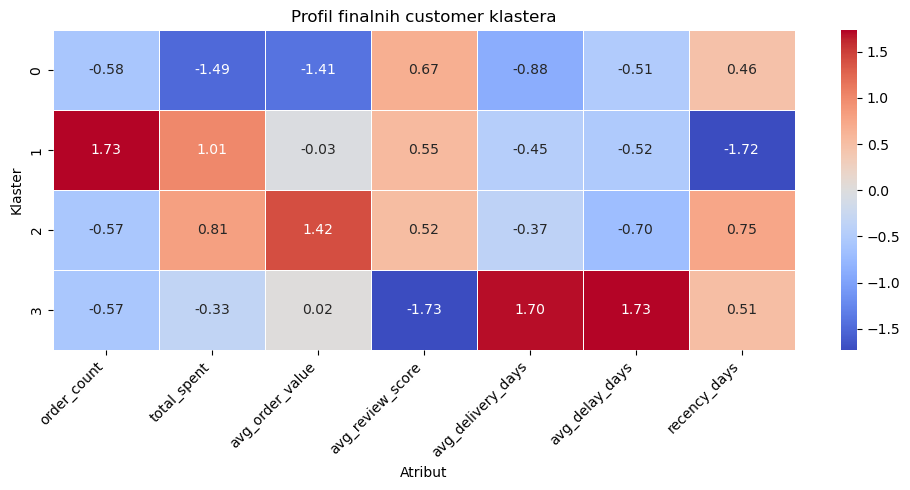

In [30]:
profile_features_short = [
    "order_count",
    "total_spent",
    "avg_order_value",
    "avg_review_score",
    "avg_delivery_days",
    "avg_delay_days",
    "recency_days"
]

profile_features_short = [
    col for col in profile_features_short
    if col in customer_master_clean.columns
]

cluster_profile_short = (
    customer_master_clean
    .groupby("customer_cluster")[profile_features_short]
    .mean()
)

cluster_profile_short_scaled = pd.DataFrame(
    StandardScaler().fit_transform(cluster_profile_short),
    index=cluster_profile_short.index,
    columns=cluster_profile_short.columns
)

import seaborn as sns

plt.figure(figsize=(10, 5))

sns.heatmap(
    cluster_profile_short_scaled,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=False
)

plt.title("Profil finalnih customer klastera")
plt.xlabel("Atribut")
plt.ylabel("Klaster")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Heatmap prikazuje standardizovane vrednosti izabranih atributa po klasterima. Svetlije vrednosti oznacavaju da je dati atribut iznad proseka, dok tamnije vrednosti oznacavaju vrednosti ispod proseka.

Na ovaj nacin se lakse uocava po cemu se pojedinacni klasteri razlikuju.

In [31]:
cluster_sizes = (
    customer_master_clean["customer_cluster"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
    .to_frame("udeo_kupaca")
)

cluster_sizes

,udeo_kupaca
customer_cluster,
0,51.76
1,2.59
2,39.21
3,6.44


Raspodela kupaca po klasterima pokazuje da KMeans formira vise interpretabilnih segmenata. Iako postoje manji klasteri, oni predstavljaju specificne grupe kupaca i ne narusavaju upotrebljivost modela.

## Kategorije proizvoda po klasterima

Najcesca preferirana kategorija proizvoda po klasteru moze ukazati na razlike u kupovnim navikama izmedju segmenata.

In [32]:
if "preferred_category" in customer_master_clean.columns:
    for cluster_id in sorted(customer_master_clean["customer_cluster"].unique()):
        print(f"Klaster {cluster_id}")
        
        display(
            customer_master_clean[
                customer_master_clean["customer_cluster"] == cluster_id
            ]["preferred_category"]
            .value_counts(normalize=True)
            .head(5)
            .mul(100)
            .round(2)
            .to_frame("udeo")
        )
        
        print("-" * 40)
else:
    print("Atribut preferred_category nije dostupan.")

Klaster 0


,udeo
preferred_category,
health_beauty,9.08
bed_bath_table,8.91
sports_leisure,7.67
computers_accessories,6.74
housewares,6.48


----------------------------------------
Klaster 1


,udeo
preferred_category,
bed_bath_table,18.63
furniture_decor,9.76
computers_accessories,7.67
health_beauty,7.67
sports_leisure,6.59


----------------------------------------
Klaster 2


,udeo
preferred_category,
bed_bath_table,9.38
health_beauty,8.58
watches_gifts,7.86
sports_leisure,7.53
computers_accessories,6.85


----------------------------------------
Klaster 3


,udeo
preferred_category,
bed_bath_table,10.33
health_beauty,9.83
sports_leisure,7.57
furniture_decor,6.65
watches_gifts,6.36


----------------------------------------


Analiza preferiranih kategorija proizvoda pokazuje da se iste kategorije pojavljuju u svim klasterima.

To ukazuje da tip proizvoda nije glavni faktor koji razdvaja kupce. Segmentacija je pre svega zasnovana na razlikama u potrosnji, aktivnosti, ocenama i karakteristikama isporuke.

Zbog toga kategorije proizvoda imaju pomocnu ulogu u interpretaciji klastera, dok najvaznije informacije dolaze iz numerickih atributa customer_master tabele.

## Interpretacija customer klastera

- **Klaster 0 – Lojalni kupci velike vrednosti** predstavlja najvredniji segment kupaca. Ovi korisnici ostvaruju najveci broj porudzbina i najvecu ukupnu potrosnju, zbog cega imaju znacajan doprinos ukupnom prometu platforme. Iako se povremeno susrecu sa kasnjenjima isporuke i daju nesto nize ocene, njihova aktivnost i vrednost kupovine izdvajaju ih od ostalih segmenata.

- **Klaster 1 – Rizicni kupci** obuhvata korisnike sa manjom aktivnoscu i nizom ukupnom potrosnjom, ali sa najduzim vremenom isporuke i najizrazenijim problemima sa kasnjenjem. Ovaj segment ostvaruje i nesto slabije ocene, sto ukazuje da logisticki problemi imaju znacajan uticaj na njihovo korisnicko iskustvo.

- **Klaster 2 – Premium kupci** cine korisnici koji ostvaruju visoku prosecnu vrednost porudzbine i relativno dobre ocene. Iako ne kupuju najcesce, pojedinacne kupovine su vrednije nego kod vecine ostalih kupaca. Zbog toga predstavljaju profitabilan segment koji generise znacajan prihod uz manji broj transakcija.

- **Klaster 3 – Povremeni zadovoljni kupci** obuhvata korisnike sa manjim brojem porudzbina i nizom ukupnom potrosnjom, ali sa stabilnim korisnickim iskustvom. Karakterisu ih bolje ocene i manje kasnjenje isporuke, zbog cega predstavljaju segment kupaca koji kupuje redje, ali je generalno zadovoljan uslugom platforme.

Analiza pokazuje da se klasteri prvenstveno razlikuju prema intenzitetu kupovine, ukupnoj potrosnji i kvalitetu korisnickog iskustva, dok tipovi proizvoda imaju znatno manji uticaj na formiranje segmenata.

# Zakljucak

U ovom notebook-u izvrseno je klasterovanje kupaca primenom algoritama KMeans i BIRCH.

Zbog velikog broja atributa nakon kodiranja kategorickih promenljivih, primenjena je PCA redukcija dimenzionalnosti. Zadrzana je reprezentacija koja cuva 90% ukupne varijanse, cime je smanjen broj atributa i povecana memorijska stabilnost algoritama.

KMeans i BIRCH su evaluirani pomocu internih metrika klasterovanja i raspodele instanci po klasterima. Nakon poredjenja odabran je finalni model, a dobijeni klasteri su interpretirani kroz originalne atribute kupaca.

Dobijeni segmenti kupaca predstavljaju osnovu za kasnije poredjenje sa rezultatima klasterovanja prodavaca i modelima za predikciju zadovoljstva kupaca.